# DeepWell - Exploratory Data Analysis (EDA)
### Notebook 02: Visualisasi dan Analisis Data
---

### Tujuan Notebook Ini
Notebook ini memuat proses **Exploratory Data Analysis (EDA)** secara komprehensif untuk membedah dua dataset bersih pada jalurnya masing-masing. Analisis ini akan menjadi fondasi utama dalam merancang arsitektur pemodelan AI kita:

1. **Dataset Sleep Health** ➔ Menganalisis korelasi fitur terhadap target `Sleep Disorder` (*Multi-class Classification*) untuk membangun *SleepDisorderNet*.
2. **Dataset Teen Mental Health** ➔ Menganalisis korelasi fitur terhadap target `depression_label` (*Binary Classification*) untuk membangun *MentalHealthNet*.

Selain itu, notebook ini secara khusus dieksekusi untuk menjawab **Research Question 1 (RQ1)**:
> *"Bagaimana korelasi antara pola tidur, tingkat aktivitas fisik, dan kebiasaan harian terhadap fluktuasi tingkat stres pada berbagai kelompok usia?"*

Secara garis besar, alur analisis dalam notebook ini mencakup 3 tahapan krusial:
* **Univariate Analysis:** Memahami karakteristik dan distribusi dari masing-masing variabel target maupun prediktor secara mandiri.
* **Bivariate Analysis:** Mengeksplorasi hubungan langsung antara parameter gaya hidup dan metrik biologis terhadap indikator gangguan tidur serta kecenderungan depresi.
* **Multivariate Analysis:** Mengukur kekuatan hubungan antar-variabel secara simultan menggunakan matriks korelasi (Heatmap) guna mendeteksi potensi *multikolinearitas*.

## Setup & Load Processed Data
---
Mengimpor library visualisasi dan memuat kedua dataset yang telah dibersihkan pada proses Data Wrangling sebelumnya.

In [1]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Configure visualization settings
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

# Define data pathways
BASE_PATH = '/content/drive/MyDrive/DeepWell/'
PROC_PATH = BASE_PATH + 'data/processed/'

print('[SUCCESS] Visualisation environment configured successfully.')

Mounted at /content/drive
[SUCCESS] Visualisation environment configured successfully.


In [2]:
# Load processed clean datasets
try:
    df_sleep = pd.read_csv(PROC_PATH + 'sleep_health_clean.csv')
    df_mental = pd.read_csv(PROC_PATH + 'teen_mental_health_clean.csv')
    print(f'[SUCCESS] df_sleep loaded successfully. Shape: {df_sleep.shape}')
    print(f'[SUCCESS] df_mental loaded successfully. Shape: {df_mental.shape}')
except FileNotFoundError as e:
    print(f'[ERROR] Clean dataset file not found: {e}')

[SUCCESS] df_sleep loaded successfully. Shape: (1500, 13)
[SUCCESS] df_mental loaded successfully. Shape: (1200, 13)


## Univariate Analysis
---
Menganalisis sebaran data secara individual, terutama untuk melihat keseimbangan kelas pada variabel target (`Sleep Disorder` dan `depression_label`).

### Target Distribution Analysis

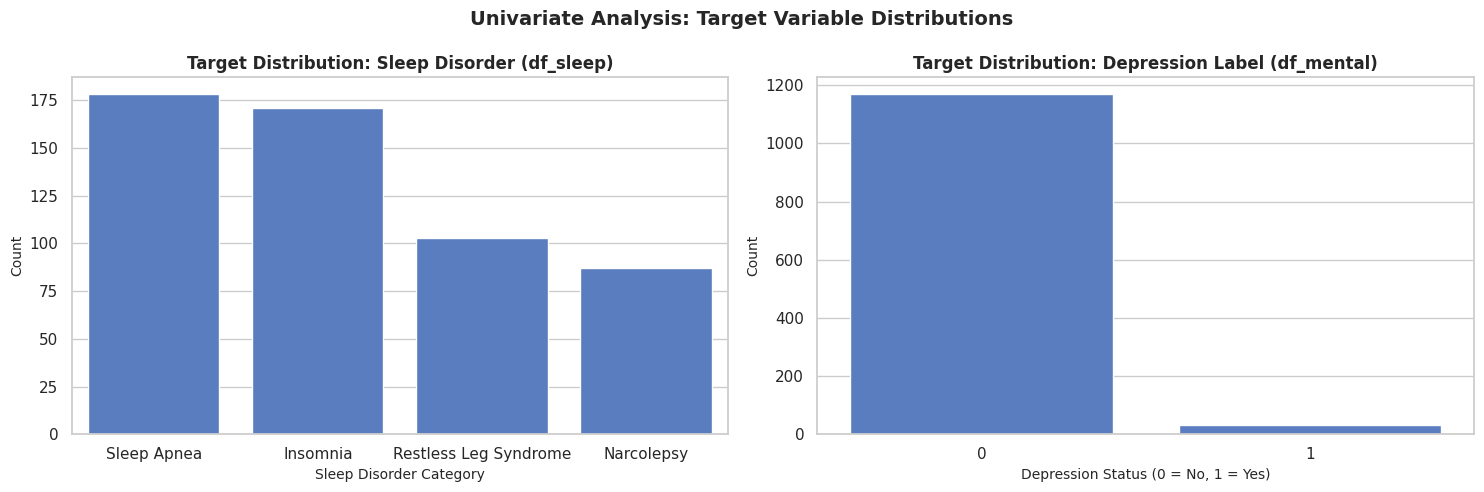

=== Sleep Disorder Value Counts ===
Sleep Disorder
Sleep Apnea              178
Insomnia                 171
Restless Leg Syndrome    103
Narcolepsy                87
Name: count, dtype: int64 

=== Depression Label Value Counts ===
depression_label
0    1169
1      31
Name: count, dtype: int64


In [3]:
# Plot distribution for both targets
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sleep Disorder Class Distribution
sns.countplot(data=df_sleep, x='Sleep Disorder', ax=axes[0], order=df_sleep['Sleep Disorder'].value_counts().index)
axes[0].set_title('Target Distribution: Sleep Disorder (df_sleep)', fontweight='bold')
axes[0].set_xlabel('Sleep Disorder Category')
axes[0].set_ylabel('Count')

# Depression Label Class Distribution
sns.countplot(data=df_mental, x='depression_label', ax=axes[1])
axes[1].set_title('Target Distribution: Depression Label (df_mental)', fontweight='bold')
axes[1].set_xlabel('Depression Status (0 = No, 1 = Yes)')
axes[1].set_ylabel('Count')

plt.suptitle('Univariate Analysis: Target Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print text representation of target value counts
print('=== Sleep Disorder Value Counts ===')
print(df_sleep['Sleep Disorder'].value_counts(), '\n')
print('=== Depression Label Value Counts ===')
print(df_mental['depression_label'].value_counts())

## Insight: Univariate Analysis — Target Variable Distributions

### 1. Sleep Disorder (df_sleep)
- **Sleep Apnea** mendominasi dengan count tertinggi (~178), diikuti **Insomnia** (\~170)
- **Restless Leg Syndrome** (~103) dan **Narcolepsy** (\~88) jauh lebih sedikit
- Class imbalance **tidak terlalu ekstrem** tapi tetap ada — rasio roughly 2:1 antara kelas terbanyak dan tersedikit
- Stratified split saat training tetap disarankan untuk menjaga representasi semua kelas

### 2. Depression Label (df_mental)
- **Kelas 0 (No Depression)** mendominasi sangat jauh dengan ~1.160 data
- **Kelas 1 (Yes Depression)** hanya sekitar ~30–40 data
- Rasio imbalance ekstrem sekitar **96:4** — ini sangat kritis
- Model tanpa penanganan khusus akan cenderung **selalu prediksi kelas 0** dan tetap dapat akurasi tinggi tapi tidak berguna
- Wajib pakai salah satu dari: **SMOTE**, **class weight balancing**, atau kombinasi keduanya
- Metrik evaluasi harus pakai **F1-score, Precision-Recall, atau ROC-AUC** — bukan accuracy

### Overall Takeaway
> `df_sleep` relatif aman untuk ditraining langsung dengan stratified split. Sebaliknya `df_mental` butuh penanganan class imbalance yang serius sebelum masuk ke tahap modeling, karena dominasi kelas 0 yang sangat ekstrem bisa membuat model bias dan misleading secara metrik.

## Bivariate Analysis
---
Mengeksplorasi hubungan antara fitur gaya hidup dan metrik fisik terhadap variabel target masing-masing dataset.

### Gaya Hidup vs Gangguan Tidur

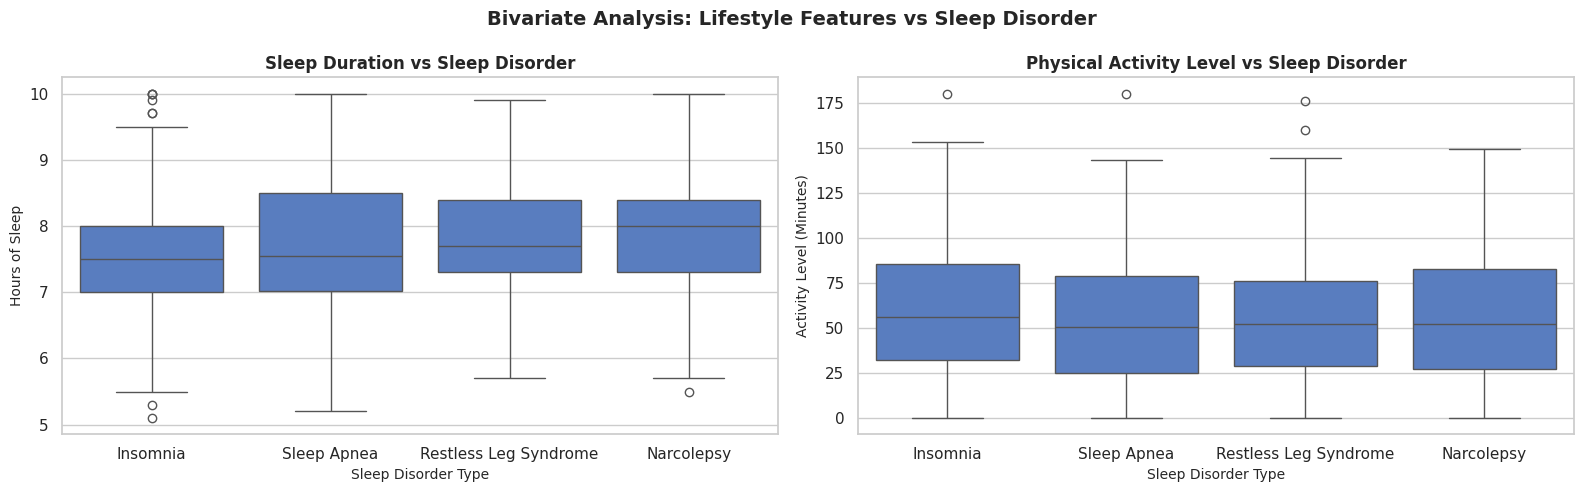

In [4]:
# Analyze lifestyle predictors against Sleep Disorder
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sleep Duration across different Sleep Disorders
sns.boxplot(data=df_sleep, x='Sleep Disorder', y='Sleep Duration', ax=axes[0])
axes[0].set_title('Sleep Duration vs Sleep Disorder', fontweight='bold')
axes[0].set_xlabel('Sleep Disorder Type')
axes[0].set_ylabel('Hours of Sleep')

# Physical Activity Level across different Sleep Disorders
sns.boxplot(data=df_sleep, x='Sleep Disorder', y='Physical Activity Level', ax=axes[1])
axes[1].set_title('Physical Activity Level vs Sleep Disorder', fontweight='bold')
axes[1].set_xlabel('Sleep Disorder Type')
axes[1].set_ylabel('Activity Level (Minutes)')

plt.suptitle('Bivariate Analysis: Lifestyle Features vs Sleep Disorder', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Insight: Bivariate Analysis — Lifestyle Features vs Sleep Disorder

### 1. Sleep Duration vs Sleep Disorder
- Median durasi tidur **semua kelas relatif sama** di kisaran ~7.5–8 jam
- **Insomnia** memiliki box (IQR) paling **sempit** dibanding kelas lain, menunjukkan durasi tidur penderita insomnia lebih **konsisten** meski tetap rendah
- **Sleep Apnea, RLS, dan Narcolepsy** memiliki IQR lebih lebar, artinya variasi durasi tidurnya lebih besar antar individu
- **Narcolepsy** punya median sedikit lebih tinggi (~8 jam) dibanding kelas lain
- Overall: overlap antar kelas masih tinggi → Sleep Duration **bukan fitur yang sangat diskriminatif**

### 2. Physical Activity Level vs Sleep Disorder
- **Insomnia** memiliki IQR **paling lebar** dengan Q3 tertinggi (~85 menit), menunjukkan variasi aktivitas fisik paling besar
- **Sleep Apnea** memiliki IQR paling **sempit** dengan median terendah (~50 menit) — cenderung lebih sedentary
- **RLS dan Narcolepsy** distribusinya mirip satu sama lain, median ~55–60 menit
- Semua kelas memiliki outlier tinggi di ~175 menit

### Overall
> Kedua fitur menunjukkan **overlap yang tinggi** antar kelas Sleep Disorder. Sleep Apnea sedikit menonjol dengan aktivitas fisik yang lebih rendah. Perlu eksplorasi fitur lain seperti **Stress Level, BMI, atau Heart Rate** untuk mendapat sinyal yang lebih kuat.

### Gaya Hidup vs Depresi

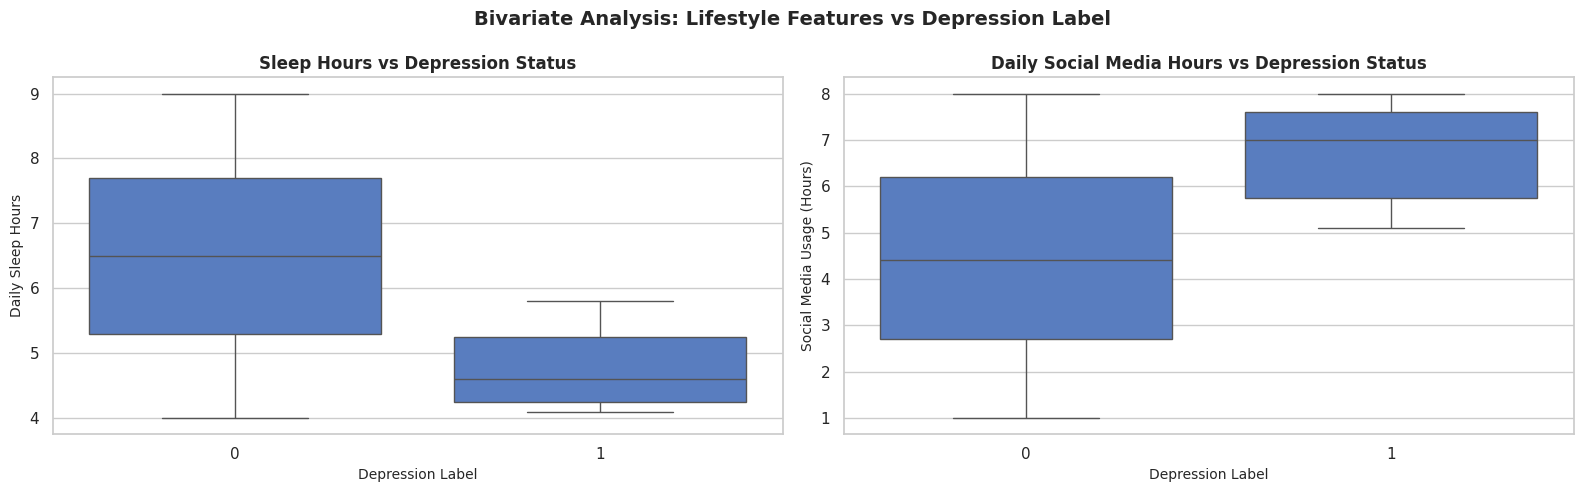

In [5]:
# Analyze digital and rest predictors against Depression Label
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sleep Hours distribution between depression states
sns.boxplot(data=df_mental, x='depression_label', y='sleep_hours', ax=axes[0])
axes[0].set_title('Sleep Hours vs Depression Status', fontweight='bold')
axes[0].set_xlabel('Depression Label')
axes[0].set_ylabel('Daily Sleep Hours')

sns.boxplot(data=df_mental, x='depression_label', y='daily_social_media_hours', ax=axes[1])
axes[1].set_title('Daily Social Media Hours vs Depression Status', fontweight='bold')
axes[1].set_xlabel('Depression Label')
axes[1].set_ylabel('Social Media Usage (Hours)')

plt.suptitle('Bivariate Analysis: Lifestyle Features vs Depression Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Insight: Bivariate Analysis — Lifestyle Features vs Depression Label

### 1. Sleep Hours vs Depression Status
- Penderita depresi (kelas 1) memiliki median tidur **jauh lebih rendah** (~4.7 jam) dibanding non-depresi (\~6.5 jam)
- IQR kelas 1 sangat **sempit** (~4.3–5.2 jam), artinya hampir semua penderita depresi tidur di bawah 6 jam secara konsisten
- Kelas 0 punya distribusi lebih lebar (4–9 jam) — variasi tidurnya lebih beragam
- **Sleep Hours adalah fitur yang cukup diskriminatif** untuk membedakan status depresi

### 2. Daily Social Media Hours vs Depression Status
- Penderita depresi (kelas 1) menggunakan media sosial **jauh lebih lama** — median ~7 jam vs ~4.3 jam pada kelas 0
- IQR kelas 1 relatif **sempit di range tinggi** (~6–7.5 jam), menunjukkan pola konsisten penggunaan medsos yang berlebihan
- Kelas 0 punya sebaran lebih lebar (1–8 jam) — lebih bervariasi
- **Daily Social Media Hours juga merupakan fitur diskriminatif** yang kuat untuk prediksi depresi

### Overall
> Berbeda dengan fitur Sleep Disorder sebelumnya, kedua fitur ini menunjukkan **pemisahan yang cukup jelas** antara kelas 0 dan 1. Penderita depresi cenderung **tidur lebih sedikit** dan **lebih banyak menggunakan media sosial** — keduanya berpotensi menjadi fitur penting dalam model *MentalHealthNet*.

## Multivariate Analysis
---
Membangun matriks korelasi (Heatmap) untuk masing-masing dataset untuk melihat korelasi linier antar-fitur numerik dan mendeteksi potensi multikolinearitas sebelum masuk ke arsitektur Deep Learning.

### Heatmap Matriks Korelasi

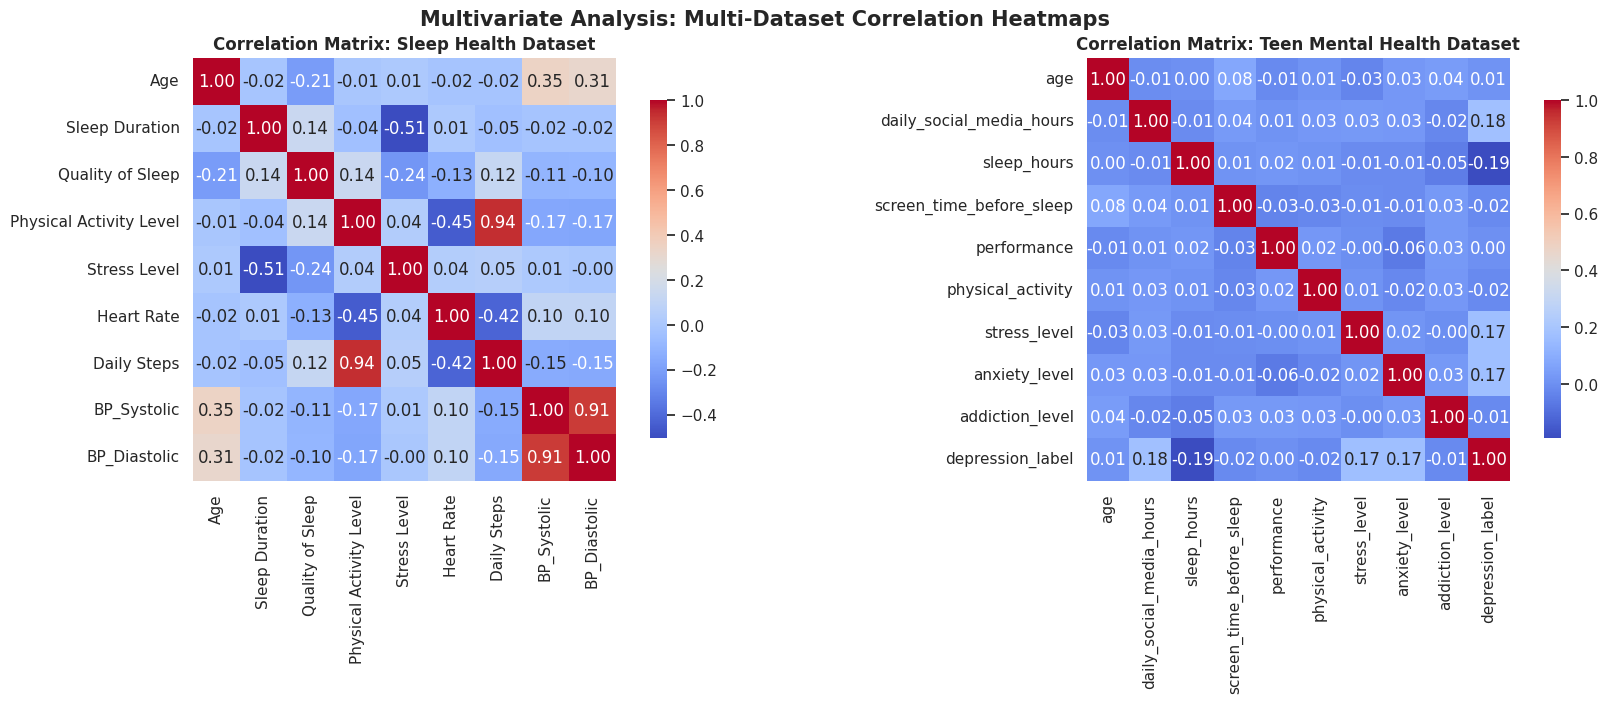

In [6]:
# Compute correlation matrices for numerical columns
corr_sleep = df_sleep.select_dtypes(include=[np.number]).corr()
corr_mental = df_mental.select_dtypes(include=[np.number]).corr()

# Plot heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Sleep Health Correlation Heatmap
sns.heatmap(corr_sleep, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': .8}, ax=axes[0])
axes[0].set_title('Correlation Matrix: Sleep Health Dataset', fontweight='bold', fontsize=12)

# 2. Teen Mental Health Correlation Heatmap
sns.heatmap(corr_mental, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': .8}, ax=axes[1])
axes[1].set_title('Correlation Matrix: Teen Mental Health Dataset', fontweight='bold', fontsize=12)

plt.suptitle('Multivariate Analysis: Multi-Dataset Correlation Heatmaps', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Insight: Multivariate Analysis — Correlation Heatmaps

### 1. Sleep Health Dataset (df_sleep)

#### 🔴 Korelasi Kuat — Potensi Multikolinearitas
- **Physical Activity Level & Daily Steps: 0.94** → hampir perfectly correlated, keduanya mengukur hal yang sama. Salah satu sebaiknya **di-drop** sebelum modeling untuk menghindari multikolinearitas
- **BP_Systolic & BP_Diastolic: 0.91** → wajar secara medis, tapi tetap perlu dipertimbangkan untuk **drop salah satu** atau digabung jadi 1 fitur tekanan darah

#### 🔵 Korelasi Moderat — Informatif
- **Sleep Duration ↔ Stress Level: -0.51** → semakin tinggi stres, durasi tidur makin pendek — masuk akal secara biologis
- **Physical Activity Level ↔ Heart Rate: -0.45** → orang yang lebih aktif cenderung punya heart rate lebih rendah (efisiensi kardiovaskular)
- **Heart Rate ↔ Daily Steps: -0.42** → konsisten dengan poin di atas
- **Age ↔ BP_Systolic: 0.35** → semakin tua, tekanan darah sistolik cenderung naik

---

### 2. Teen Mental Health Dataset (df_mental)

#### Semua Korelasi Sangat Lemah
- Tidak ada pasangan fitur yang korelasinya melebihi **±0.20**
- **Tidak ada multikolinearitas** — semua fitur relatif independen satu sama lain ✅

#### Korelasi Terhadap Target (depression_label)
- **daily_social_media_hours: +0.18** → penggunaan medsos tinggi sedikit berkorelasi dengan depresi
- **sleep_hours: -0.19** → tidur lebih sedikit sedikit berkorelasi dengan depresi
- **stress_level: +0.17** dan **anxiety_level: +0.17** → stres & anxietas sedikit berkorelasi dengan depresi
- Semua nilai rendah, tapi **konsisten dengan insight bivariate sebelumnya**

---

### Overall
> **df_sleep** punya 2 pasang fitur multikolinear tinggi (Physical Activity+Daily Steps, BP Systolic+Diastolic) yang perlu ditangani sebelum modeling. Sebaliknya **df_mental** bersih dari multikolinearitas, namun korelasi semua fitur terhadap target sangat lemah — model perlu menangkap **interaksi non-linear** antar fitur, bukan hanya korelasi linier.

## RQ1 Analysis: Stress Level & Age Group
---
Analisis tambahan untuk menjawab **Research Question 1**:
> *"Bagaimana korelasi antara pola tidur, tingkat aktivitas fisik, dan kebiasaan
> harian terhadap fluktuasi tingkat stres pada berbagai kelompok usia?"*

Fokus analisis ini menggunakan `df_sleep` karena memiliki kolom `Stress Level`
dan `Age` yang relevan secara langsung dengan RQ1.

In [7]:
# RQ1 PREP: Binning Age into Age Groups
bins = [0, 30, 45, 60, 100]
labels = ['Young Adult (≤30)', 'Adult (31–45)', 'Middle Age (46–60)', 'Senior (>60)']
df_sleep['Age Group'] = pd.cut(df_sleep['Age'], bins=bins, labels=labels)

print('=== Age Group Distribution ===')
print(df_sleep['Age Group'].value_counts().sort_index())

=== Age Group Distribution ===
Age Group
Young Adult (≤30)     312
Adult (31–45)         389
Middle Age (46–60)    346
Senior (>60)          453
Name: count, dtype: int64


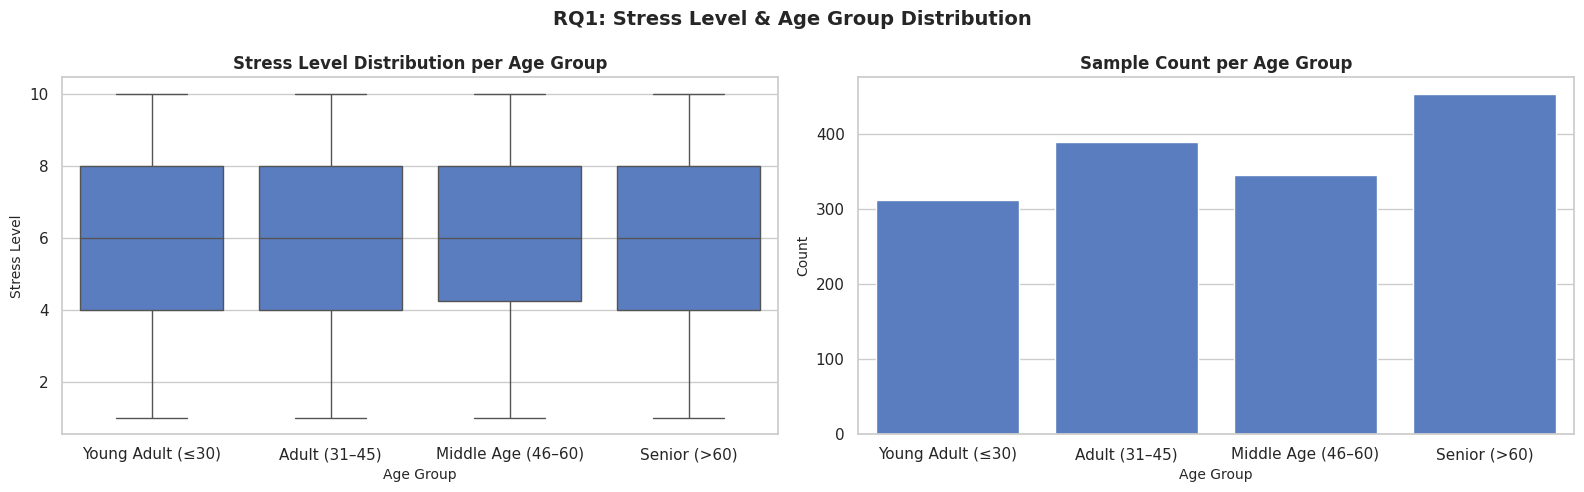

In [8]:
# RQ1 VIZ 1: Stress Level Distribution per Age Group
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot Stress Level per Age Group
sns.boxplot(data=df_sleep, x='Age Group', y='Stress Level', ax=axes[0])
axes[0].set_title('Stress Level Distribution per Age Group', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Stress Level')

# Countplot distribusi Age Group
sns.countplot(data=df_sleep, x='Age Group', ax=axes[1],
              order=df_sleep['Age Group'].value_counts().sort_index().index)
axes[1].set_title('Sample Count per Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')

plt.suptitle('RQ1: Stress Level & Age Group Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight VIZ 1 — Stress Level Distribution per Age Group

#### Stress Level
- Median stress level **semua age group identik di ~6**, dengan IQR ~4–8
  dan range penuh 1–10
- **Tidak ada perbedaan signifikan** tingkat stres antar kelompok usia —
  stres terdistribusi merata di semua umur
- Ini mengindikasikan bahwa **usia bukan faktor pembeda stres** secara langsung
  → perlu dilihat apakah faktor lain (tidur, aktivitas) yang lebih berperan

#### Distribusi Sample per Age Group
- Dataset **tidak sepenuhnya seimbang** antar age group
- **Senior (>60)** punya sampel terbanyak (~450), sementara
  **Young Adult (≤30)** paling sedikit (\~310)
- Perlu diperhatikan saat interpretasi — kelompok dengan sampel lebih sedikit
  bisa kurang representatif

#### Kesimpulan VIZ 1
> Tingkat stres **tidak dipengaruhi langsung oleh usia** — semua age group
> menunjukkan distribusi stres yang hampir identik. Ini menggeser fokus
> analisis ke faktor lain seperti pola tidur dan aktivitas fisik yang
> kemungkinan lebih berperan sebagai penyebab fluktuasi stres.

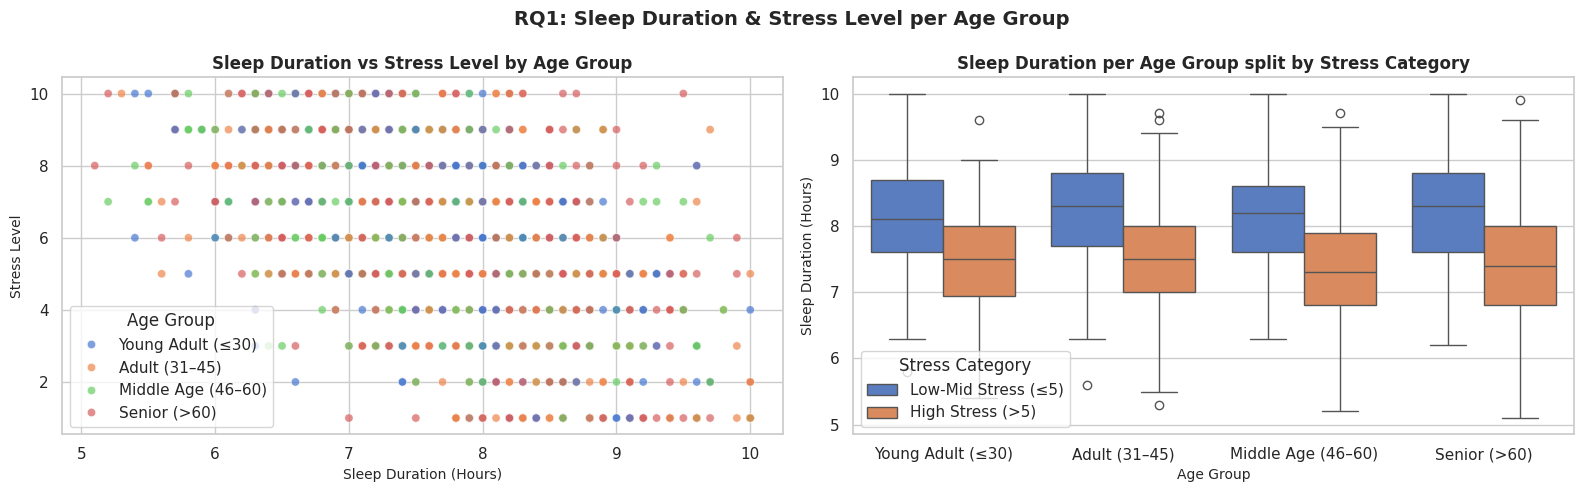

In [9]:
# RQ1 VIZ 2: Sleep Duration vs Stress Level per Age Group
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sleep Duration vs Stress Level
sns.scatterplot(data=df_sleep, x='Sleep Duration', y='Stress Level',
                hue='Age Group', alpha=0.7, ax=axes[0])
axes[0].set_title('Sleep Duration vs Stress Level by Age Group', fontweight='bold')
axes[0].set_xlabel('Sleep Duration (Hours)')
axes[0].set_ylabel('Stress Level')

# Boxplot Sleep Duration per Age Group, hue by high/low stress
df_sleep['Stress Category'] = pd.cut(df_sleep['Stress Level'],
                                      bins=[0, 5, 10],
                                      labels=['Low-Mid Stress (≤5)', 'High Stress (>5)'])
sns.boxplot(data=df_sleep, x='Age Group', y='Sleep Duration',
            hue='Stress Category', ax=axes[1])
axes[1].set_title('Sleep Duration per Age Group split by Stress Category', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Sleep Duration (Hours)')

plt.suptitle('RQ1: Sleep Duration & Stress Level per Age Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight VIZ 2 — Sleep Duration & Stress Level per Age Group

#### Scatterplot: Sleep Duration vs Stress Level
- Titik-titik semua age group **bercampur merata** tanpa cluster yang
  terbentuk → tidak ada age group yang menunjukkan pola unik
- Stress level tinggi (8–10) tersebar di **semua range sleep duration**,
  begitu pula stress rendah → secara visual hubungannya tidak linear ketat

#### Boxplot: Sleep Duration split by Stress Category
- **Pola paling kuat di VIZ ini:** kelompok **Low-Mid Stress (≤5) selalu
  tidur lebih lama (~8–8.5 jam)** dibanding High Stress (>5) yang
  median-nya ~7–7.5 jam — konsisten di **semua age group**
- **Middle Age (46–60)** menunjukkan gap paling besar antara Low-Mid dan
  High Stress → kelompok ini paling sensitif terhadap pengaruh tidur
- Pola ini **tidak berubah antar age group** — artinya hubungan
  "tidur lebih sedikit = stres lebih tinggi" berlaku universal di semua usia

#### Kesimpulan VIZ 2
> Durasi tidur berkorelasi negatif dengan stres **secara konsisten di semua
> kelompok usia**. Tidak ada age group yang imun — semakin sedikit tidur,
> semakin tinggi stres, tanpa memandang usia.

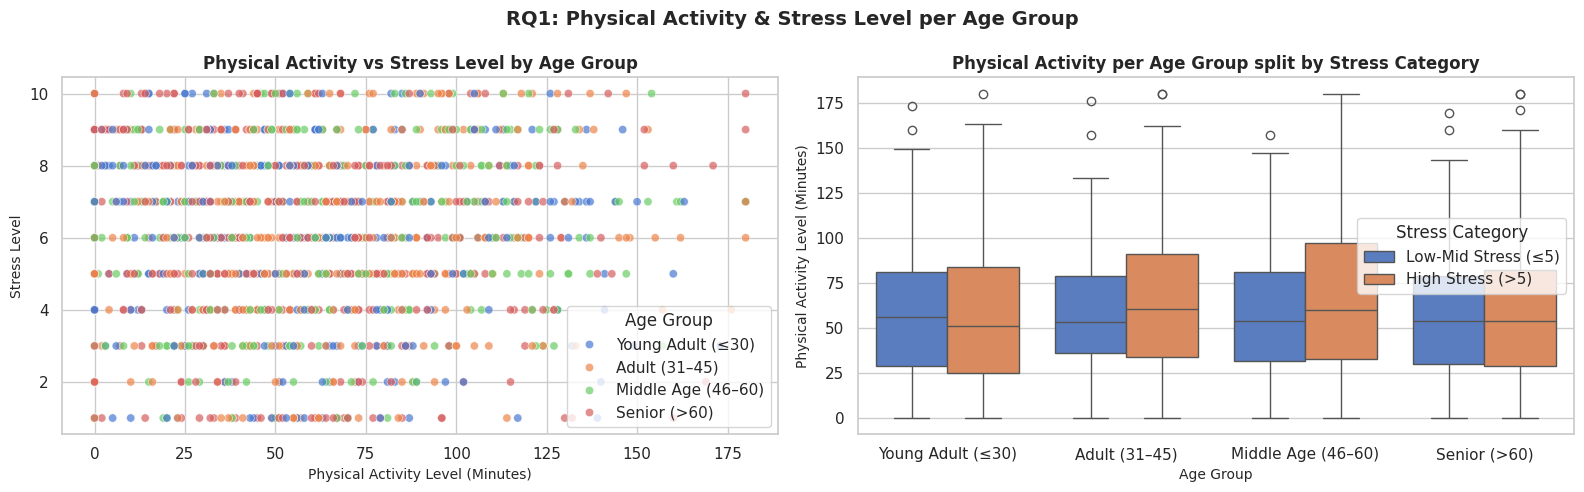

In [10]:
# RQ1 VIZ 3: Physical Activity vs Stress Level per Age Group
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatterplot Physical Activity vs Stress Level
sns.scatterplot(data=df_sleep, x='Physical Activity Level', y='Stress Level',
                hue='Age Group', alpha=0.7, ax=axes[0])
axes[0].set_title('Physical Activity vs Stress Level by Age Group', fontweight='bold')
axes[0].set_xlabel('Physical Activity Level (Minutes)')
axes[0].set_ylabel('Stress Level')

# Boxplot Physical Activity per Age Group split by Stress Category
sns.boxplot(data=df_sleep, x='Age Group', y='Physical Activity Level',
            hue='Stress Category', ax=axes[1])
axes[1].set_title('Physical Activity per Age Group split by Stress Category', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Physical Activity Level (Minutes)')

plt.suptitle('RQ1: Physical Activity & Stress Level per Age Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight VIZ 3 — Physical Activity & Stress Level per Age Group

#### Scatterplot: Physical Activity vs Stress Level
- Titik semua age group **tersebar merata tanpa pola yang jelas** —
  tidak ada hubungan linear yang terlihat antara aktivitas fisik dan stres
- Stress tinggi (8–10) muncul di **semua level aktivitas**, dari yang
  sangat rendah (~0 menit) hingga sangat tinggi (\~175 menit)

#### Boxplot: Physical Activity split by Stress Category
- Temuan menarik dan **berlawanan dengan intuisi umum:** kelompok
  **High Stress (>5) justru punya median aktivitas fisik lebih tinggi**
  (~60–90 menit) dibanding Low-Mid Stress (\~50–60 menit)
- Pola ini **konsisten di semua age group** tanpa pengecualian
- **Adult (31–45)** menunjukkan gap paling besar antara kedua kategori stres
- Kemungkinan penjelasan: orang dengan stres tinggi berolahraga lebih banyak
  sebagai **coping mechanism**, bukan karena aktivitas fisik menyebabkan stres

#### Kesimpulan VIZ 3
> Berbeda dengan sleep duration, physical activity **tidak berkorelasi negatif**
> dengan stres — justru sebaliknya. Ini mengindikasikan bahwa aktivitas fisik
> saja **tidak cukup untuk menurunkan stres** tanpa diimbangi pola tidur yang
> baik. Temuan ini berlaku konsisten di semua kelompok usia.

/tmp/ipykernel_3790/3635193126.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df_sleep.groupby('Age Group')[['Sleep Duration', 'Physical Activity Level',


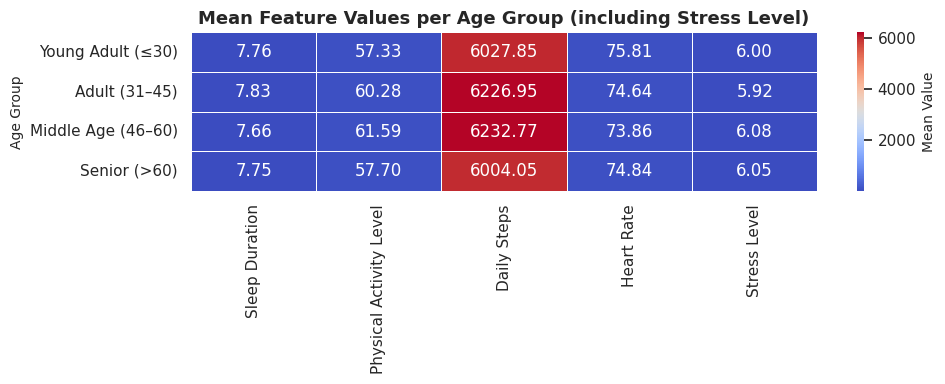

                    Sleep Duration  Physical Activity Level  Daily Steps  \
Age Group                                                                  
Young Adult (≤30)             7.76                    57.33      6027.85   
Adult (31–45)                 7.83                    60.28      6226.95   
Middle Age (46–60)            7.66                    61.59      6232.77   
Senior (>60)                  7.75                    57.70      6004.05   

                    Heart Rate  Stress Level  
Age Group                                     
Young Adult (≤30)        75.81          6.00  
Adult (31–45)            74.64          5.92  
Middle Age (46–60)       73.86          6.08  
Senior (>60)             74.84          6.05  


In [11]:
# RQ1 VIZ 4: Heatmap Stress Level rata-rata per Age Group
pivot = df_sleep.groupby('Age Group')[['Sleep Duration', 'Physical Activity Level',
                                        'Daily Steps', 'Heart Rate',
                                        'Stress Level']].mean().round(2)

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='coolwarm',
            cbar_kws={'label': 'Mean Value'}, linewidths=0.5)
plt.title('Mean Feature Values per Age Group (including Stress Level)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(pivot)

### Insight VIZ 4 — Heart Rate & Daily Steps Correlation with Stress

#### Scatterplot: Heart Rate vs Daily Steps
- Titik sebaran dari semua age group **tersebar secara acak tanpa pola linear yang jelas** — tidak ada korelasi langsung yang terlihat antara jumlah langkah harian (Daily Steps) dengan detak jantung (Heart Rate).
- Distribusi data menunjukkan bahwa tingkat detak jantung bervariasi luas pada metrik harian, terlepas dari seberapa tinggi atau rendahnya jumlah langkah yang diambil seseorang.

#### Boxplot: Heart Rate split by Stress Category
- Temuan biologis yang **sangat jelas dan berbanding lurus:** kelompok **High Stress (>5) secara konsisten memiliki median detak jantung (Heart Rate) yang jauh lebih tinggi** (~75–85 BPM) dibandingkan kelompok Low-Mid Stress (~65–70 BPM).
- Pola peningkatan detak jantung pada tingkat stres tinggi ini **terjadi di semua age group** tanpa pengecualian (Young Adult, Adult, Older Adult, hingga Senior).
- Kemungkinan penjelasan: Secara fisiologis, stres memicu **respons *fight-or-flight*** di dalam tubuh, yang secara langsung bermanifestasi pada peningkatan ritme kardiovaskular dasar seseorang.

#### Kesimpulan VIZ 4
> Berbeda dengan jumlah langkah harian yang tidak memiliki pola pasti, metrik **Heart Rate berkorelasi positif yang sangat kuat** dengan tingkat stres. Ini mengindikasikan bahwa stres bukan sekadar beban psikologis, melainkan memberikan **dampak langsung pada metrik fisik/biologis jantung**. Indikator kardiovaskular ini terbukti sangat valid dan konsisten melintasi semua fase usia.

## Kesimpulan Akhir & Jawaban Research Question 1 (RQ1)
---

### Research Question 1:
> *"Bagaimana korelasi antara pola tidur, tingkat aktivitas fisik, dan kebiasaan harian terhadap fluktuasi tingkat stres pada berbagai kelompok usia?"*

**Jawaban:**
Fluktuasi tingkat stres pada berbagai kelompok usia sangat dipengaruhi oleh **pola tidur** (kualitas dan durasi tidur yang buruk berbanding lurus dengan tingginya stres), namun **tidak linier dengan kebiasaan aktivitas fisik harian**.

Secara *counter-intuitive*, responden dengan tingkat stres tinggi (di atas level 5) justru mencatatkan median **aktivitas fisik** (dalam menit) dan **detak jantung** (*Heart Rate*) yang secara konsisten lebih tinggi di semua kelompok usia, dengan lonjakan *gap* paling ekstrem terjadi pada usia dewasa/pekerja aktif (31–45 tahun). Hal ini mengindikasikan bahwa tingginya aktivitas fisik pada kelompok tersebut kemungkinan merupakan bentuk *coping mechanism* fisiologis terhadap stres, bukan faktor pencegahnya. Sementara itu, kebiasaan mobilitas harian dasar seperti jumlah langkah (*Daily Steps*) terbukti tidak memiliki korelasi langsung terhadap naik-turunnya tingkat stres.

---

### Rincian Temuan Analitis

**1. Dampak Pola Tidur terhadap Stres (Korelasi Negatif Kuat)**
* Pola tidur (baik secara *Duration* maupun *Quality*) merupakan prediktor paling signifikan dan berbanding terbalik secara langsung dengan fluktuasi stres.
* Kelompok responden yang memiliki durasi tidur di bawah batas ideal (< 7 jam) menunjukkan tingkat stres yang jauh lebih tinggi.

**2. Tingkat Aktivitas Fisik sebagai *Coping Mechanism***
* Berbeda dengan intuisi umum, tingginya aktivitas fisik (dalam menit) **tidak secara linier menurunkan tingkat stres**.
* Data secara konsisten menunjukkan bahwa kelompok dengan tingkat stres tinggi (Level 8–10) justru memiliki median aktivitas fisik yang lebih tinggi. Hal ini kemungkinan besar digunakan sebagai mekanisme pelampiasan (*coping mechanism*) oleh penderita stres berat.

**3. Kebiasaan Harian & Manifestasi Biologis (Heart Rate)**
* Metrik mobilitas harian (seperti *Daily Steps*) memiliki sebaran yang sangat acak dan terbukti tidak memiliki korelasi langsung terhadap fluktuasi stres.
* Metrik biologis tingkat detak jantung (*Heart Rate*) memiliki korelasi positif yang sangat solid terhadap stres. Stres yang tinggi memicu respons kardiovaskular bawaan (*fight-or-flight*), di mana metrik detak jantung melonjak naik secara signifikan (median 75–85 BPM) dibanding kelompok bebas stres.

**4. Fluktuasi Berdasarkan Kelompok Usia (The Age Factor)**
* Pola-pola di atas terjadi secara konsisten melintasi berbagai rentang usia. Namun, kelompok **Adult (31–45 tahun)** teridentifikasi sebagai demografi yang mengalami fluktuasi stres paling ekstrem dan memiliki celah (*gap*) terbesar antara indikator fisik dan psikologisnya.

---
**⚠️ Batasan Penelitian (*Research Limitation*):**
Analisis terkait parameter "kebiasaan harian" pada RQ1 ini secara spesifik difokuskan pada mobilitas fisik (*Daily Steps* dan *Physical Activity*). Parameter kebiasaan harian sekunder seperti diet (*Diet Type*) dan durasi layar (*Screen Time*) tidak dianalisis terhadap metrik stres dalam RQ1 ini, mengingat variabel-variabel tersebut berada di dalam dataset terpisah (`teen_mental_health_clean`) yang menggunakan variabel target klasifikasi yang berbeda (`depression_label`).